# Full ColorFeret cGAN Training
This notebook orchestrates end-to-end training on the complete 2722 frontal images of the ColorFeret dataset.
It uses the pre-uploaded Kaggle dataset and linked pretrained weights securely to train the GitHub repository on Kaggle.

## 1. Check Kaggle GPU & Setup Environment

In [1]:
import os
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Clone the GitHub Repository

In [2]:
!rm -rf stylized-portrait-generation
!git clone https://github.com/supratimcoder1/stylized-portrait-generation.git
%cd stylized-portrait-generation

Cloning into 'stylized-portrait-generation'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 76 (delta 34), reused 59 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 1.43 MiB | 9.89 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/kaggle/working/stylized-portrait-generation


## 3. Install Dependencies

In [3]:
%pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## 4. Verify Split Dataset & Weights Location

In [4]:
# Assumes Kaggle Dataset names: color-feret-splits and best-model-pth
base_dir = "/kaggle/input/datasets/supratimghosh01/color-feret-frontal-dataset/full_dataset"
splits = ["train_images", "train_targets", "val_images", "val_targets"]
weights_path = "/kaggle/input/datasets/supratimghosh01/pretrained-model-for-colorferet/best_model.pth"

print(f"Using split dataset base: {base_dir}")
for split in splits:
    path = os.path.join(base_dir, split)
    exists = os.path.exists(path)
    count = len(os.listdir(path)) if exists else 0
    print(f"{split} exists: {exists} | files: {count}")
print(f"Pretrained weights exist: {os.path.exists(weights_path)}")

Using split dataset base: /kaggle/input/datasets/supratimghosh01/color-feret-frontal-dataset/full_dataset
train_images exists: True | files: 2449
train_targets exists: True | files: 2449
val_images exists: True | files: 273
val_targets exists: True | files: 273
Pretrained weights exist: True


## 5. Create Split Symlinks and Model Setup
Link read-only Kaggle split folders into the repo's expected dataset/ layout.

In [5]:
!rm -rf dataset
!mkdir -p dataset
!mkdir -p checkpoints

# Symlink split folders expected by training/train.py
!ln -s "$base_dir/train_images" dataset/train_images
!ln -s "$base_dir/train_targets" dataset/train_targets
!ln -s "$base_dir/val_images" dataset/val_images
!ln -s "$base_dir/val_targets" dataset/val_targets
!ln -s {weights_path} checkpoints/best_model.pth

print("Linked dataset layout:")
!ls -la dataset/
print("\nLinked checkpoints layout:")
!ls -la checkpoints/

Linked dataset layout:
total 24
drwxr-xr-x 2 root root 4096 Mar 24 14:55 .
drwxr-xr-x 8 root root 4096 Mar 24 14:55 ..
lrwxrwxrwx 1 root root   92 Mar 24 14:55 train_images -> /kaggle/input/datasets/supratimghosh01/color-feret-frontal-dataset/full_dataset/train_images
lrwxrwxrwx 1 root root   93 Mar 24 14:55 train_targets -> /kaggle/input/datasets/supratimghosh01/color-feret-frontal-dataset/full_dataset/train_targets
lrwxrwxrwx 1 root root   90 Mar 24 14:55 val_images -> /kaggle/input/datasets/supratimghosh01/color-feret-frontal-dataset/full_dataset/val_images
lrwxrwxrwx 1 root root   91 Mar 24 14:55 val_targets -> /kaggle/input/datasets/supratimghosh01/color-feret-frontal-dataset/full_dataset/val_targets

Linked checkpoints layout:
total 12
drwxr-xr-x 2 root root 4096 Mar 24 14:55 .
drwxr-xr-x 8 root root 4096 Mar 24 14:55 ..
lrwxrwxrwx 1 root root   85 Mar 24 14:55 best_model.pth -> /kaggle/input/datasets/supratimghosh01/pretrained-model-for-colorferet/best_model.pth


## 6. Start Training

In [6]:
!python training/train.py --epochs 50 --batch-size 8 --output-dir /kaggle/working/training_outputs --checkpoint-dir ./checkpoints

Training on cuda
Loading pretrained generator state from ./checkpoints/best_model.pth
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|█████████████████████████████████████████| 528M/528M [00:02<00:00, 215MB/s]
Epoch 1/50: 100%|████████████████████████████████████████████████████████████| 307/307 [02:26<00:00,  2.10it/s, D_Loss=0.639, G_Loss=9.775] 
Epoch 1 | G Loss: 8.6969 | D Loss: 0.6928 | Val L1: 0.0452
Saved new best model to ./checkpoints/final_model.pth (Val L1: 0.0452)
Epoch 2/50: 100%|████████████████████████████████████████████████████████████| 307/307 [02:32<00:00,  2.01it/s, D_Loss=0.679, G_Loss=8.460] 
Epoch 2 | G Loss: 8.6699 | D Loss: 0.6307 | Val L1: 0.0464
Epoch 3/50: 100%|████████████████████████████████████████████████████████████| 307/307 [02:32<00:00,  2.01it/s, D_Loss=0.642, G_Loss=8.686] 
Epoch 3 | G Loss: 8.7795 | D Loss: 0.6044 | Val L1: 0.0497
Epoch 4/50: 100%|██████████████████

## 7. Inspect Training Outputs

Showing: /kaggle/working/training_outputs/epoch_9.png


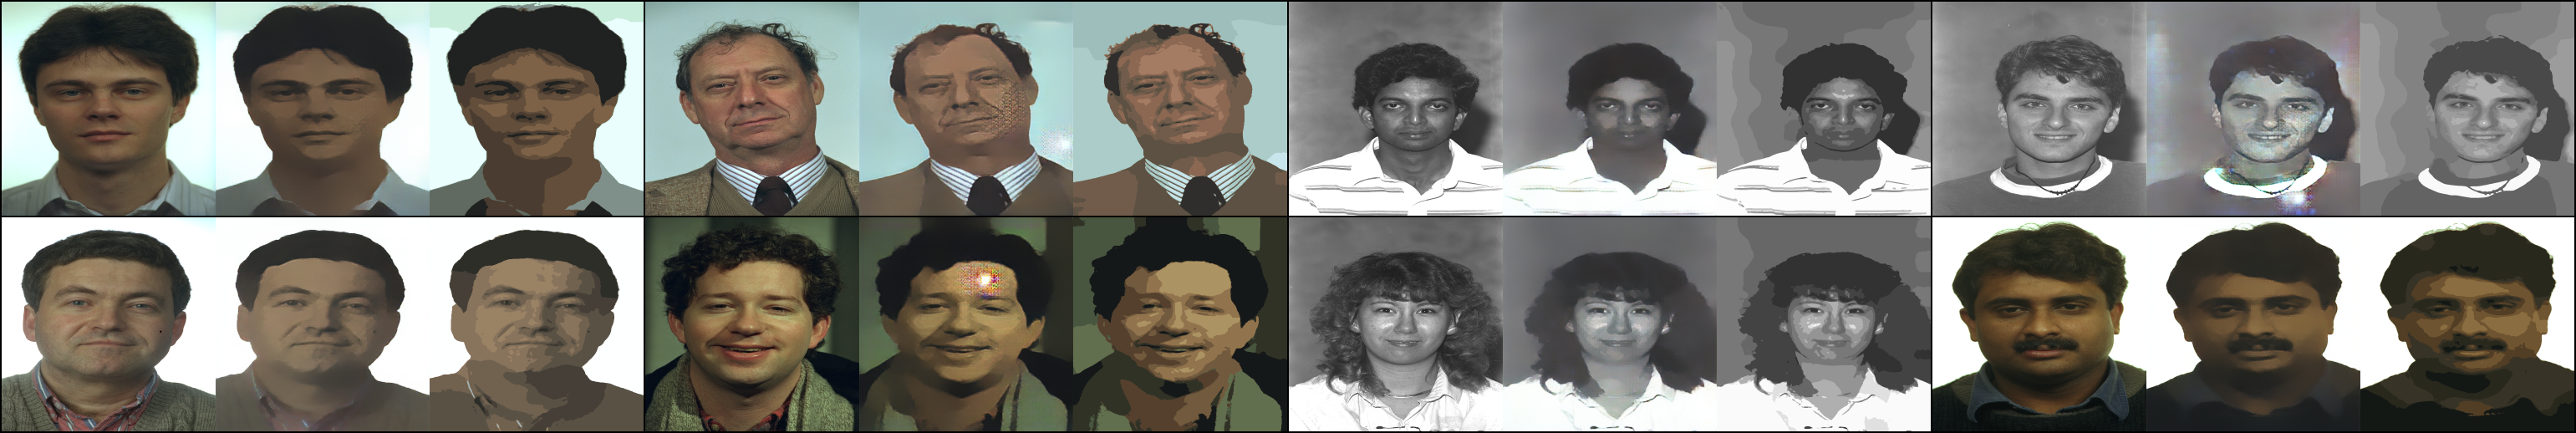

In [7]:
import glob
from IPython.display import display, Image as IPImage

sample_files = sorted(glob.glob("/kaggle/working/training_outputs/epoch_*.png"))
if sample_files:
    latest = sample_files[-1]
    print(f"Showing: {latest}")
    display(IPImage(filename=latest, width=800))
else:
    print("No sample images found - training may not have completed.")

## 8. Download Best Trained Model

In [8]:
model_path = "./checkpoints/final_model.pth"
if os.path.exists(model_path):
    !zip -j /kaggle/working/final_model.zip {model_path}
    print("Best model zipped to /kaggle/working/final_model.zip")
else:
    print("final_model.pth not found. Check training logs and checkpoint directory.")

  adding: final_model.pth (deflated 7%)
Best model zipped to /kaggle/working/final_model.zip
